# Průzkumná analýza dat

Notebook slouží jako příloha pro základní průzkumnou analýzu dat disciplíny 100 m s překážkami před importem do databáze.


## Načtení dat


In [221]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

for _ in range(5):
    if (PROJECT_ROOT / "docs").exists() and (PROJECT_ROOT / "data").exists():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"PROJECT_ROOT: {PROJECT_ROOT}")


PROJECT_ROOT: /Users/adelaleppeltova/firesport-app


In [222]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from docs.analysis import (
    add_quality_flags,
    find_inconsistent_team_names,
    find_missing_attempts,
    find_possible_duplicate_athletes,
    get_competitions,
    get_results,
    load_json_files_from_dir,
    results_to_dataframe,
    summarize_data_quality,
    summarize_dataset,
    summarize_final_times,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:.2f}")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.figsize": (8, 4.5),
    "grid.alpha": 0.32,
    "grid.color": "#C7CDD6",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "#C9CFD6",
})


In [223]:
DATA_DIR = PROJECT_ROOT / "data"

records = load_json_files_from_dir(DATA_DIR)
competitions = get_competitions(records)
results = get_results(records)

df_competitions = pd.DataFrame(competitions)
df_results = add_quality_flags(results_to_dataframe(results))

valid_results = df_results.loc[
    (df_results["final_status"] == "valid")
    & df_results["final_time"].notna()
    & ~df_results["suspicious_final_time"]
].copy()

df_results["year"] = df_results["competition_date"].dt.year
df_results["month"] = df_results["competition_date"].dt.month
df_results["year_month"] = df_results["competition_date"].dt.to_period("M").astype(str)

len(records), len(df_competitions), len(df_results)


(329, 329, 13854)

## Charakteristika a souhrn datasetu


In [224]:
dataset_summary = summarize_dataset(df_results)
pd.Series(dataset_summary)


athlete_count              4708
result_count              13854
competition_count            65
min_date             2019-05-04
max_date             2025-10-04
disciplines              [100m]
dtype: object

In [225]:
pd.Series({
    "Počet záznamů": len(df_results),
    "Počet závodníků": dataset_summary["athlete_count"],
    "Počet závodů": dataset_summary["competition_count"],
    "Počet kategorií": df_results["category_name"].dropna().nunique(),
})


Počet záznamů      13854
Počet závodníků     4708
Počet závodů          65
Počet kategorií       11
dtype: int64

In [226]:
final_time_summary = summarize_final_times(df_results)
pd.Series(final_time_summary)


mean     20.27
median   19.72
min      14.64
max      57.13
std       2.92
dtype: float64

In [227]:
df_results[[
    "competition_date",
    "competition_name",
    "category_name",
    "discipline",
    "athlete_full_name",
    "team",
    "final_time",
    "final_status",
]].head(10)


,competition_date,competition_name,category_name,discipline,athlete_full_name,team,final_time,final_status
0,2019-06-02,Běloveský kilo,Muži,100m,Patrik Kligl,Běloves,15.43,valid
1,2019-06-02,Běloveský kilo,Muži,100m,Lukáš Kroupa,Kvasiny B,16.01,valid
2,2019-06-02,Běloveský kilo,Muži,100m,Jan Zhříval,HZS Hradec Králové,16.13,valid
3,2019-06-02,Běloveský kilo,Muži,100m,Michal Gierlowski,Tuř,17.34,valid
4,2019-06-02,Běloveský kilo,Muži,100m,Pavel Hoffman,Běloves,17.52,valid
5,2019-06-02,Běloveský kilo,Muži,100m,David Hoffman,Běloves,17.59,valid
6,2019-06-02,Běloveský kilo,Muži,100m,Dominik Mašek,Ruda,17.68,valid
7,2019-06-02,Běloveský kilo,Muži,100m,Jakub Vondra,Stolín,18.19,valid
8,2019-06-02,Běloveský kilo,Muži,100m,Stanislav Pavlas,Vidochov,18.63,valid
9,2019-06-02,Běloveský kilo,Muži,100m,Lukáš Kligl,Běloves,18.72,valid


## Rozdělení výkonů


Pro základní popis rozdělení výkonů byly analyzovány validní finální časy. Kvartily a medián byly vypočteny z celého souboru validních výsledků, zatímco histogram byl pro přehlednost omezen na interval 14–28 s.


In [228]:
final_time_stats_source = valid_results["final_time"].dropna()

median = final_time_stats_source.median()
q1 = final_time_stats_source.quantile(0.25)
q3 = final_time_stats_source.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

histogram_results = valid_results[
    valid_results["final_time"].between(14, 28)
].copy()

histogram_table = (
    pd.cut(histogram_results["final_time"], bins=24)
    .value_counts()
    .sort_index()
    .rename_axis("time_interval")
    .reset_index(name="result_count")
)

df_intervals = histogram_table.copy()

display(pd.Series({
    "median": median,
    "q1": q1,
    "q3": q3,
    "iqr": iqr,
    "upper_bound": upper_bound,
    "histogram_result_count": len(histogram_results),
}))

df_intervals


median                      19.72
q1                          18.41
q3                          21.35
iqr                          2.94
upper_bound                 25.76
histogram_result_count   13027.00
dtype: float64

,time_interval,result_count
0,"(14.627, 15.197]",5
1,"(15.197, 15.753]",24
2,"(15.753, 16.31]",121
3,"(16.31, 16.867]",332
4,"(16.867, 17.423]",774
5,"(17.423, 17.98]",1125
6,"(17.98, 18.537]",1241
7,"(18.537, 19.093]",1411
8,"(19.093, 19.65]",1492
9,"(19.65, 20.207]",1348


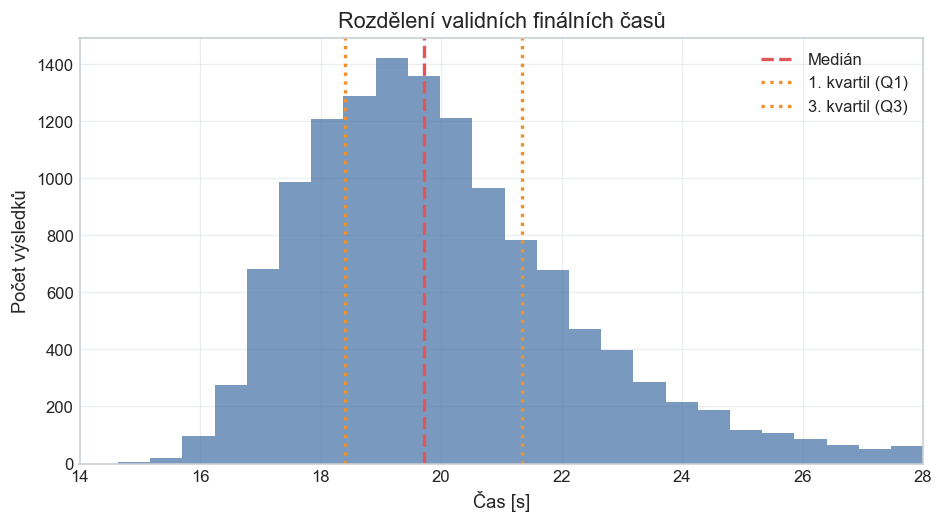

In [229]:
plt.figure(figsize=(8, 4.5))
sns.histplot(
    histogram_results["final_time"],
    bins=25,
    kde=False,
    color="#4C78A8",
    edgecolor=None,
)

plt.axvline(median, color="#E15759", linestyle="--", linewidth=2, label="Medián")
plt.axvline(q1, color="#F28E2B", linestyle=":", linewidth=2, label="1. kvartil (Q1)")
plt.axvline(q3, color="#F28E2B", linestyle=":", linewidth=2, label="3. kvartil (Q3)")

plt.title("Rozdělení validních finálních časů")
plt.xlabel("Čas [s]")
plt.ylabel("Počet výsledků")
plt.xlim(14, 28)
plt.legend()

plt.tight_layout()
plt.show()


In [230]:
category_distribution = (
    df_results.groupby(["category_name", "discipline"])
    .size()
    .reset_index(name="result_count")
    .sort_values("result_count", ascending=False)
)

category_name_map = {
    "Střední dorostenky": "Stř. dorostenky",
    "Střední dorostenci": "Stř. dorostenci",
    "Mladší dorostenky": "Ml. dorostenky",
    "Mladší dorostenci": "Ml. dorostenci",
    "Starší dorostenky": "St. dorostenky",
    "Starší dorostenci": "St. dorostenci",
    "Dorostenky": "Dorostenky",
    "Dorostenci": "Dorostenci",
    "Ženy": "Ženy",
    "Muži": "Muži",
}

category_distribution["short_category_name"] = category_distribution["category_name"].map(category_name_map).fillna(category_distribution["category_name"])
category_distribution["share_percent"] = 100 * category_distribution["result_count"] / category_distribution["result_count"].sum()

top_categories = category_distribution.head(8).copy()

display(pd.Series({
    "top_1_category": top_categories.iloc[0]["short_category_name"],
    "top_1_share_percent": top_categories.iloc[0]["share_percent"],
    "top_3_share_percent": top_categories.head(3)["share_percent"].sum(),
}))

top_categories[["short_category_name", "discipline", "result_count", "share_percent"]]


top_1_category         Muži
top_1_share_percent   18.43
top_3_share_percent   46.65
dtype: object

,short_category_name,discipline,result_count,share_percent
4,Muži,100m,2409,18.43
10,Ženy,100m,2230,17.06
9,Stř. dorostenky,100m,1460,11.17
8,Stř. dorostenci,100m,1446,11.06
3,Ml. dorostenky,100m,1102,8.43
6,St. dorostenci,100m,855,6.54
7,St. dorostenky,100m,838,6.41
1,Dorostenky,100m,735,5.62


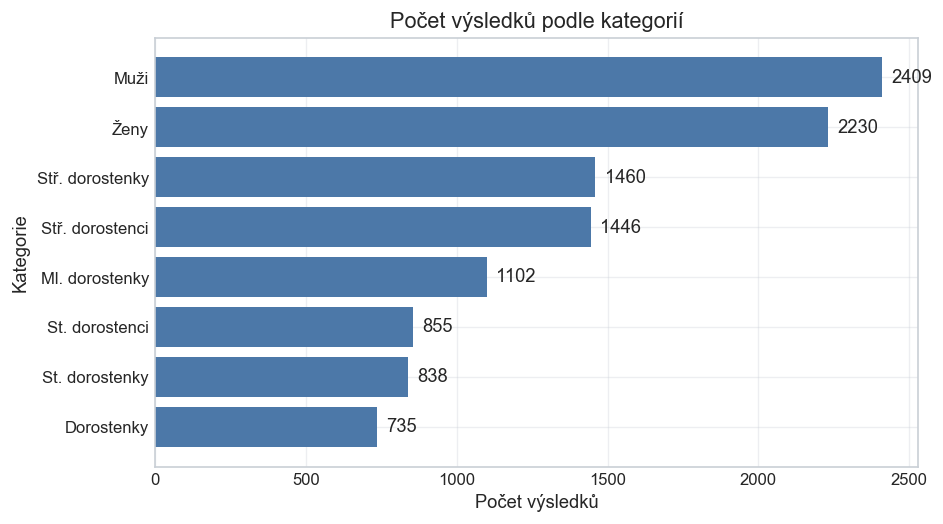

In [231]:
top_categories = category_distribution.sort_values("result_count", ascending=True).tail(8)

plt.figure(figsize=(8, 4.5))
bars = plt.barh(top_categories["short_category_name"], top_categories["result_count"], color="#4C78A8")

plt.title("Počet výsledků podle kategorií")
plt.xlabel("Počet výsledků")
plt.ylabel("Kategorie")

for bar in bars:
    width = bar.get_width()
    plt.text(width + 30, bar.get_y() + bar.get_height() / 2, f"{int(width)}", va="center")

plt.tight_layout()
plt.show()


In [232]:
q1 = valid_results["final_time"].quantile(0.25)
q3 = valid_results["final_time"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = valid_results[
    (valid_results["final_time"] < lower_bound)
    | (valid_results["final_time"] > upper_bound)
].copy()

pd.Series({
    "q1": q1,
    "q3": q3,
    "lower_bound": lower_bound,
    "upper_bound": upper_bound,
    "outlier_count": len(outliers),
})


q1               18.41
q3               21.35
lower_bound      14.00
upper_bound      25.76
outlier_count   583.00
dtype: float64

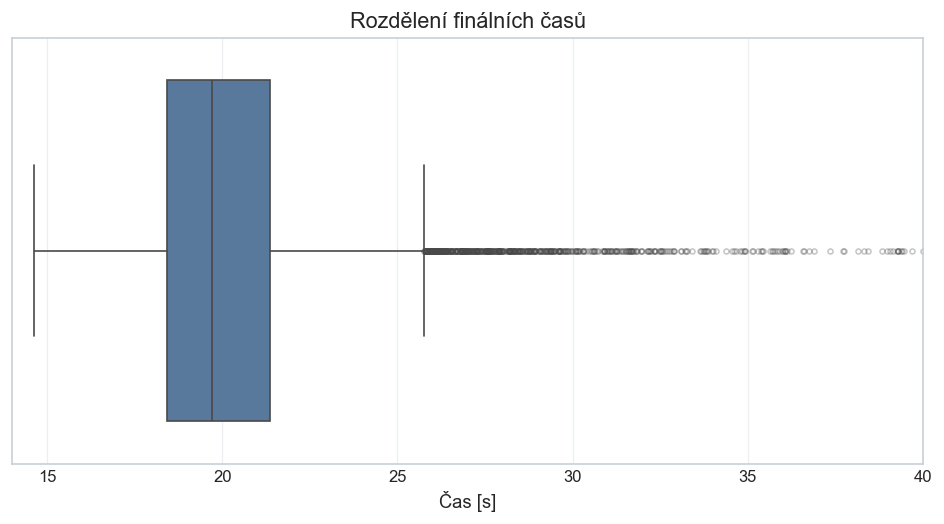

In [233]:
plt.figure(figsize=(8, 4.5))
sns.boxplot(
    x=valid_results["final_time"],
    color="#4C78A8",
    flierprops=dict(marker="o", markersize=3, alpha=0.3),
)

plt.title("Rozdělení finálních časů")
plt.xlabel("Čas [s]")
plt.xlim(14, 40)

plt.tight_layout()
plt.show()


## Kvalita dat


In [234]:
quality_summary = summarize_data_quality(df_results)
pd.Series(quality_summary)


missing_birth_year_count       6233
missing_fscode_count           6155
missing_team_count                2
missing_attempts_count            0
suspicious_final_time_count     524
duplicate_rows_count              0
dtype: int64

Následující přehled shrnuje hlavní problémy kvality dat identifikované v analyzovaném souboru před importem do databáze.


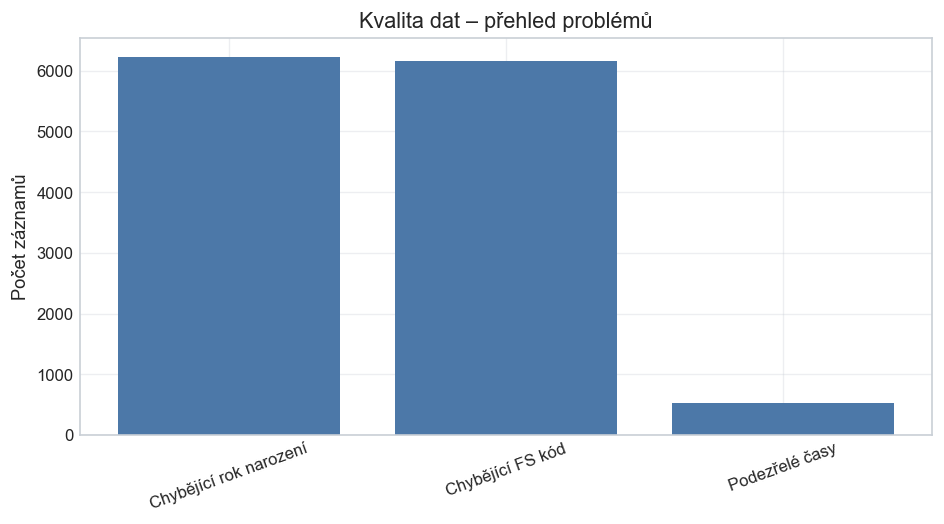

In [235]:
labels = [
    "Chybějící rok narození",
    "Chybějící FS kód",
    "Podezřelé časy",
]

values = [
    quality_summary["missing_birth_year_count"],
    quality_summary["missing_fscode_count"],
    quality_summary["suspicious_final_time_count"],
]

plt.figure()
plt.bar(labels, values, color="#4C78A8")

plt.title("Kvalita dat – přehled problémů")
plt.ylabel("Počet záznamů")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


In [236]:
outlier_ratio = pd.Series({
    "outlier_count": len(outliers),
    "total_valid_results": len(valid_results),
    "outlier_ratio_percent": 100 * len(outliers) / len(valid_results) if len(valid_results) else None,
    "outlier_ratio_text": f"{len(outliers)} / {len(valid_results)}",
})

outlier_ratio


outlier_count                    583
total_valid_results            13330
outlier_ratio_percent           4.37
outlier_ratio_text       583 / 13330
dtype: object

## Identifikace problémů v datech


In [237]:
possible_duplicate_athletes = find_possible_duplicate_athletes(df_results)

print(f"Počet možných duplicitních identit závodníků: {len(possible_duplicate_athletes)}")
display(possible_duplicate_athletes.head(5))


Počet možných duplicitních identit závodníků: 852


,athlete_full_name,team_count,fscode_count,birth_year_count,teams,fs_codes,birth_years,result_count
0,Lukáš Kroupa,6,1,1,"[Kvasiny B, Pardubice - Polabiny, Pardubice- Polabiny, Pardubice-Polabiny, VHJ Pardubice, Zbožnov]",[17681.0],[1997.0],35
1,Šimon Šuba,3,1,1,"[Císařov, Milotice nad Bečvou, Oznice]",[29131.0],[2006.0],33
2,Jakub Mikulík,4,1,1,"[Bludov, Býškovice, Hostinné, SLATINY, Slatiny]",[49721.0],[2004.0],31
3,Matyáš Novák,4,2,2,"[Krouna, Seč, Stará Říše, Výčapy]","[50901.0, 94551.0]","[2006.0, 2007.0]",31
4,Vít Vymazal,4,1,1,"[Morkovice, Oznice, SLATINY, Seč, Slatiny]",[28381.0],[2006.0],30


In [238]:
inconsistent_team_names = find_inconsistent_team_names(df_results)

print(f"Počet skupin s nekonzistentními názvy týmů: {len(inconsistent_team_names)}")
display(inconsistent_team_names.head(5))


Počet skupin s nekonzistentními názvy týmů: 19


,team_key,variant_count,variants,result_count
0,bukovice,2,"[BUKOVICE, Bukovice]",322
1,slatiny,2,"[SLATINY, Slatiny]",148
2,hzs kraje vysočina,2,"[HZS Kraje Vysočina, HZS kraje Vysočina]",68
3,chábory,2,"[CHÁBORY, Chábory]",58
4,opočno,2,"[OPOČNO, Opočno]",50


In [239]:
missing_attempts = find_missing_attempts(df_results)

print(f"Počet záznamů s chybějícími nebo nekompletními pokusy: {len(missing_attempts)}")
display(missing_attempts[[
    "competition_date",
    "discipline",
    "athlete_full_name",
    "team",
    "times",
    "has_missing_attempts",
]].head(5))


Počet záznamů s chybějícími nebo nekompletními pokusy: 0


,competition_date,discipline,athlete_full_name,team,times,has_missing_attempts


,problem,count
0,Chybějící rok narození,6233
1,Chybějící FS kód,6155
2,Možné duplicitní identity závodníků,852
4,Odlehlé hodnoty finálního času,583
3,Nekonzistentní názvy týmů,19
5,Neúplné údaje o pokusech,0


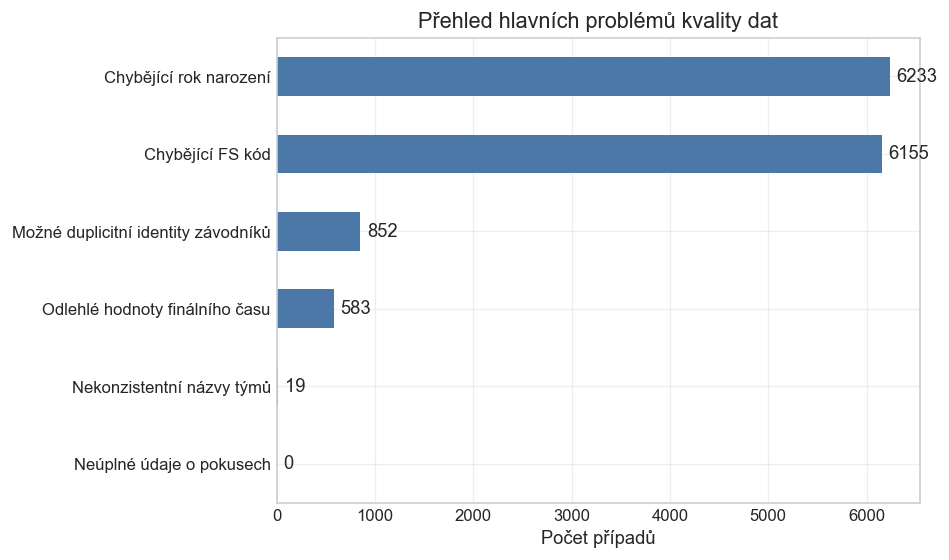

In [240]:
cleaning_problem_chart = pd.DataFrame({
    "problem": [
        "Chybějící rok narození",
        "Chybějící FS kód",
        "Možné duplicitní identity závodníků",
        "Nekonzistentní názvy týmů",
        "Odlehlé hodnoty finálního času",
        "Neúplné údaje o pokusech",
    ],
    "count": [
        quality_summary["missing_birth_year_count"],
        quality_summary["missing_fscode_count"],
        len(possible_duplicate_athletes),
        len(inconsistent_team_names),
        len(outliers),
        len(missing_attempts),
    ],
})

cleaning_problem_chart = cleaning_problem_chart.sort_values("count", ascending=False)
display(cleaning_problem_chart)

ax = cleaning_problem_chart.sort_values("count").plot(
    kind="barh",
    x="problem",
    y="count",
    color="#4C78A8",
    legend=False,
    figsize=(8, 4.8),
)

ax.set_title("Přehled hlavních problémů kvality dat")
ax.set_xlabel("Počet případů")
ax.set_ylabel("")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=4)

plt.tight_layout()
plt.show()


## Časové pokrytí


In [241]:
results_by_year = (
    df_results.groupby("year")
    .size()
    .rename("result_count")
    .reset_index()
    .sort_values("year")
)

results_by_year


,year,result_count
0,2019,2075
1,2020,729
2,2021,1672
3,2022,2192
4,2023,2475
5,2024,2245
6,2025,2466


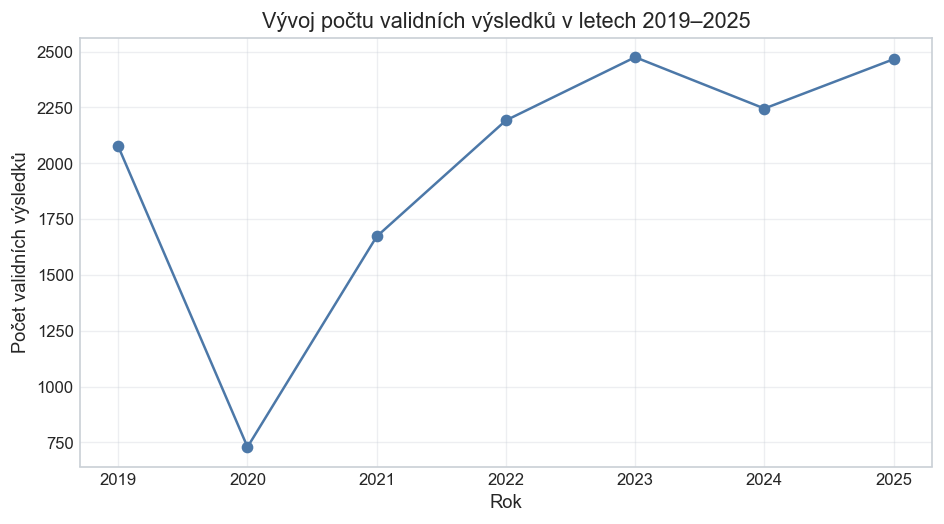

In [242]:
results_by_year_plot = results_by_year.copy()

plt.figure(figsize=(8, 4.5))
plt.plot(results_by_year_plot["year"], results_by_year_plot["result_count"], marker="o", color="#4C78A8")

plt.title("Vývoj počtu validních výsledků v letech 2019–2025")
plt.xlabel("Rok")
plt.ylabel("Počet validních výsledků")



plt.tight_layout()
plt.show()


In [243]:
seasonality = (
    df_results.groupby("month")
    .size()
    .rename("result_count")
    .reset_index()
    .sort_values("month")
)

month_labels = {
    1: "leden", 2: "únor", 3: "březen", 4: "duben", 5: "květen", 6: "červen",
    7: "červenec", 8: "srpen", 9: "září", 10: "říjen", 11: "listopad", 12: "prosinec",
}

seasonality["month_name"] = seasonality["month"].map(month_labels)
seasonality["share_percent"] = 100 * seasonality["result_count"] / seasonality["result_count"].sum()

display(pd.Series({
    "top_month": seasonality.loc[seasonality["result_count"].idxmax(), "month_name"],
    "top_month_share_percent": seasonality["share_percent"].max(),
    "lowest_month": seasonality.loc[seasonality["result_count"].idxmin(), "month_name"],
    "lowest_month_share_percent": seasonality["share_percent"].min(),
}))

seasonality[["month", "month_name", "result_count", "share_percent"]]


top_month                     červenec
top_month_share_percent          36.05
lowest_month                     říjen
lowest_month_share_percent        0.60
dtype: object

,month,month_name,result_count,share_percent
0,4,duben,105,0.76
1,5,květen,1895,13.68
2,6,červen,1475,10.65
3,7,červenec,4995,36.05
4,8,srpen,4461,32.20
5,9,září,840,6.06
6,10,říjen,83,0.60


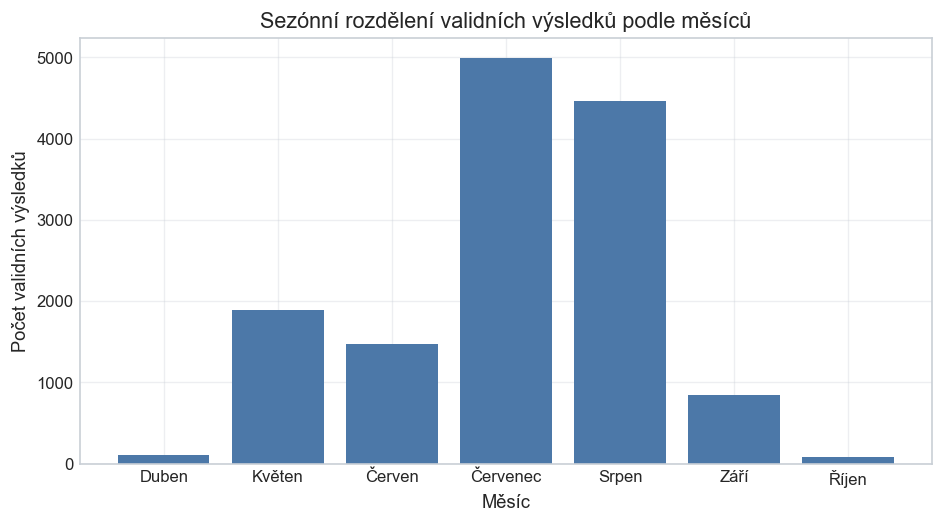

In [244]:
seasonality_plot_data = seasonality[(seasonality["month"] >= 4) & (seasonality["month"] <= 10)].copy()

plt.figure()
plt.bar(seasonality_plot_data["month"], seasonality_plot_data["result_count"], color="#4C78A8")

plt.title("Sezónní rozdělení validních výsledků podle měsíců")
plt.xlabel("Měsíc")
plt.ylabel("Počet validních výsledků")

plt.xticks(
    ticks=[4, 5, 6, 7, 8, 9, 10],
    labels=["Duben", "Květen", "Červen", "Červenec", "Srpen", "Září", "Říjen"],
)

plt.tight_layout()
plt.show()


In [245]:
coverage_by_month = (
    df_results.groupby("year_month")
    .size()
    .rename("result_count")
    .reset_index()
    .sort_values("year_month")
)

coverage_by_month["rolling"] = (
    coverage_by_month["result_count"]
    .rolling(window=3, min_periods=1)
    .mean()
)

coverage_by_month.head(24)


,year_month,result_count,rolling
0,2019-05,518,518.00
1,2019-06,76,297.00
2,2019-07,534,376.00
3,2019-08,947,519.00
4,2020-06,281,587.33
5,2020-07,234,487.33
6,2020-08,214,243.00
7,2021-06,118,188.67
8,2021-07,945,425.67
9,2021-08,402,488.33


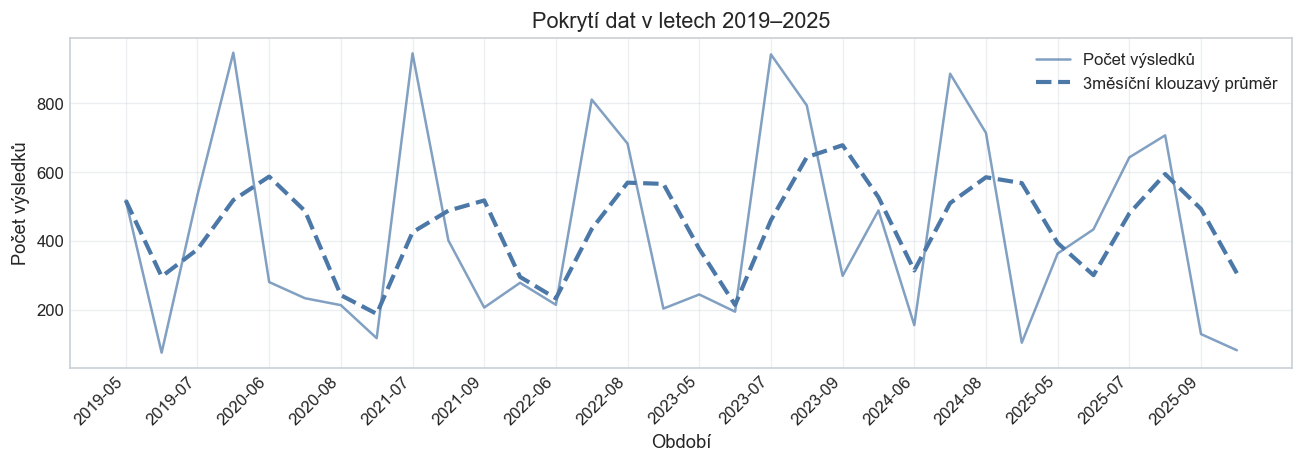

In [246]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(
    coverage_by_month["year_month"],
    coverage_by_month["result_count"],
    color="#4C78A8",
    linewidth=1.5,
    alpha=0.7,
    label="Počet výsledků",
)
ax.plot(
    coverage_by_month["year_month"],
    coverage_by_month["rolling"],
    color="#4C78A8",
    linewidth=2.5,
    linestyle="--",
    label="3měsíční klouzavý průměr",
)
ax.set_title("Pokrytí dat v letech 2019–2025")
ax.set_xlabel("Období")
ax.set_ylabel("Počet výsledků")
tick_step = max(1, len(coverage_by_month) // 12)
tick_positions = list(range(0, len(coverage_by_month), tick_step))
ax.set_xticks(tick_positions)
ax.set_xticklabels(coverage_by_month.iloc[tick_positions]["year_month"], rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()


In [247]:
coverage_summary = pd.Series({
    "year_count": df_results["year"].dropna().nunique(),
    "month_count": df_results["year_month"].replace("NaT", pd.NA).dropna().nunique(),
    "min_results_per_year": results_by_year["result_count"].min() if not results_by_year.empty else None,
    "max_results_per_year": results_by_year["result_count"].max() if not results_by_year.empty else None,
    "min_results_per_month": coverage_by_month["result_count"].min() if not coverage_by_month.empty else None,
    "max_results_per_month": coverage_by_month["result_count"].max() if not coverage_by_month.empty else None,
})

coverage_summary


year_count                  7
month_count                32
min_results_per_year      729
max_results_per_year     2475
min_results_per_month      76
max_results_per_month     947
dtype: int64

## Shrnutí hlavních zjištění

- Dataset obsahuje výsledky z let 2019–2025 a zahrnuje více kategorií disciplíny 100 m s překážkami.
- Rozdělení validních finálních časů je pravostranně vychýlené, s nejvyšší koncentrací přibližně mezi 18 a 21 s.
- Nejvýznamnější problémy kvality dat představují chybějící rok narození, chybějící FS kód a možné duplicitní identity závodníků.
- Časové pokrytí dat není rovnoměrné; výrazný pokles počtu výsledků je patrný v roce 2020.
